# E0 — Batch Size Sweep Analysis — UNet2D on ISIC 2017

**Question.** What is the optimal per-GPU training batch size for a 2D U-Net on ISIC 2017 on a dual-T4 target?

**Design.** Two sweeps over `bs ∈ {4, 8, 16, 32, 64, 128}` (10 epochs each, single GPU): one without augmentation (`no_aug`) and one with standard training augmentations (`with_aug`). 

**Source.** `mlflow-the-batch-size-sweep-experiment.db` + `…-augm.db` — 12 runs per experiment (1 run × 6 batch sizes), single GPU (`fit/devices: 1`).


## Executive summary

- Sweep: bs ∈ {4, 8, 16, 32, 64, 128}, 10 epochs each, single GPU (T4 16 GB); augmentations on and off
- Selection criterion: smallest bs that simultaneously sits on the throughput plateau, stays compute-bound and saturates the GPU

| Metric | bs=4 | bs=8 | **bs=16** | bs=32 | bs=64 | bs=128 |
|---|---|---|---|---|---|---|
| Throughput no_aug (sps) | 127.2 | 205.9 | **167.1** | 157.2 | 158.6 | 146.9 |
| Throughput with_aug (sps) | 136.2 | 213.0 | **167.9** | 168.5 | 166.5 | 160.4 |
| GPU util no_aug (%) | 45 | 52 | **77** | 88 | 100 | 94 |
| GPU util with_aug (%) | 45 | 53 | **80** | 88 | 91 | 100 |
| Peak GPU mem (GB) | 0.22 | 0.39 | **0.72** | 1.39 | 2.74 | 5.36 |

**Findings:**
- Throughput peaks at bs=8 (206 / 213 sps), from bs=16 onward it is flat (∼81 % of peak)
- GPU utilisation first crosses ∼80 % at bs=16
- Peak GPU memory at bs=16: 0.72 GB — well within the 16 GB T4 envelope, ample DDP headroom
- Augmentation overhead at bs=16 is negligible, given data at hand

**Decision: freeze `bs = 16` for all subsequent experiments.**

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import sys; sys.path.insert(0, "/teamspace/studios/this_studio/repos/SkiNet")

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from SkiNet.Utils.analysis.batch_sweep import (
    gpu_summary,
    load_experiments,
    recommendation_facts,
    throughput_summary,
)
from SkiNet.Utils.analysis.plotting import (
    plot_empirical_throughput_and_timing,
    plot_gpu_panels,
    plot_loss_curves,
    plot_throughput_traces,
    scatter_outliers,
)
from SkiNet.Utils.analysis.schema import (
    EXPECTED_BATCH_SIZES,
    MAX_EPOCHS_SWEEP,
)

sys.path.insert(0, "/teamspace/studios/this_studio/repos/SkiNet")

# ── Configuration — every tunable argument lives in this cell ────────────────
PROJECT_ROOT = Path("/teamspace/studios/this_studio/repos/SkiNet")

DB_PATHS = {
    "no_aug":   PROJECT_ROOT / "mlflow-the-batch-size-sweep-experiment.db",   # no augmentation
    "with_aug": PROJECT_ROOT / "mlflow-the-batch-size-sweep-experiment-augm.db",  # with augmentation
}
RECOMMENDED_BS = 16  # judgment call — four-criterion rationale in Section 5

# ── Presentation ─────────────────────────────────────────────────────────────
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:.4f}".format)


In [2]:
# ── Load: 12 runs = 2 conditions × 6 batch sizes ─────────────────────────────
DF = load_experiments(DB_PATHS)

Loaded 19723 rows:
                       rows
experiment batch_size      
no_aug     4           5000
           8           2500
           16          1250
           32           630
           64           321
           128          160
with_aug   4           5000
           8           2501
           16          1251
           32           630
           64           320
           128          160


## 1. Data

One row per `(experiment, batch_size, step)`. Key columns:

- **`experiment`** — condition: `no_aug` (baseline) or `with_aug` (standard training augmentations applied per-batch)
- **`batch_size`** — per-GPU batch size ∈ {4, 8, 16, 32, 64, 128}
- **`run_uuid`** — MLflow run identifier; one UUID per `(experiment, batch_size)` run
- **`step`** — optimiser step index within the run (0-based)
- **`samples_per_sec`** — training throughput logged every step, the **primary selection signal**
- **`time_per_step_ms`** — wall-clock cost per optimiser step
- **`epoch_idx`** — epoch index the step belongs to; used to mark epoch boundaries in the throughput/loss traces
- **`gpu_mem_gb`** — peak allocated GPU memory per step (sampled by `pynvml`; `NaN` on steps where the GPU metrics sampler didn't run on that training step)
- **`gpu_util_pct`** — GPU Streaming Multiprocessor's utilisation percent per step (sampled by `pynvml`; `NaN` on steps where the GPU metrics sampler didn't run on that training step)
- **`train_loss`** — step-level training loss (for context only)
- **`is_outlier`** — rule-flagged (step 0, epoch boundaries) and IQR-flagged steps excluded from all throughput statistics. See below for the exact detection rules
- **`outlier_reason`** — reason a step was flagged: `step0` (warm-up spike), `epoch_last_high` / `epoch_first_low` (epoch-boundary artefacts), `iqr` (two-sided 3× IQR fence), or empty for clean steps

In [3]:
DF.head()

,experiment,batch_size,run_uuid,step,samples_per_sec,time_per_step_ms,epoch_idx,gpu_mem_gb,gpu_util_pct,train_loss,is_outlier,outlier_reason
0,no_aug,32,0684085d224c4f73a2a77ae49a36ca17,0,61.6536,519.0288,0.0000,NaN,NaN,0.9174,True,step0
1,no_aug,32,0684085d224c4f73a2a77ae49a36ca17,1,160.9083,198.8710,0.0000,0.0125,0.0000,0.7916,False,
2,no_aug,32,0684085d224c4f73a2a77ae49a36ca17,2,163.4368,195.7943,0.0000,NaN,NaN,0.5656,False,
3,no_aug,32,0684085d224c4f73a2a77ae49a36ca17,3,164.1081,194.9935,0.0000,NaN,NaN,0.5126,False,
4,no_aug,32,0684085d224c4f73a2a77ae49a36ca17,4,160.0101,199.9874,0.0000,NaN,NaN,0.5818,False,


## 2. Selection methodology

Note that the batch size is treated as a **training-speed knob** and is not used to optimise the model itself, i.e. is not acting as a tunable hyperparameter (Shallue et al. 2018; Google Deep Learning Tuning Playbook). 

### 2.1 Outlier detection

Before any throughput statistic is computed, every per-step `samples_per_sec` observation is audited for three known artefacts:

| Flag | Rule | Reason |
|---|---|---|
| **Step0** | Any observation at `step == 0` | CUDA JIT compilation — including cuDNN autotuning on the first-seen input shape as well as the first (cold) data fetch |
| **Epoch boundary** | The last and first step of every epoch, flagged unconditionally | The last step of an epoch typically processes the ragged (smaller) final batch and measures fast (`epoch_last_high`); the first step of the next epoch absorbs the re-shuffle and DataLoader restart and measures slow (`epoch_first_low`). Neither reflects steady-state throughput |
| **IQR** | `samples_per_sec < Q1 − 3 x IQR` **or** `> Q3 + 3 x IQR` within each `(experiment, batch_size)` run, applied to steps that survived the two rule-based flags | **1) Fast steps:** The DataLoader prefetched the next batch before the GPU finished the previous step, so the measured `elapsed` time interval excludes data-wait time and throughput spikes (**upward dataloader jitter**) <br> **2) Slow steps:** - GPU waiting because prefetch didn't finish in time (**downward dataloader jitter**); - The caching GPU memory allocator can't serve a tensor from its reserved memory pool (early in a run while the pool is still growing to its steady-state size or when the pool is near the memory ceiling) |

Steps matching any flag are marked `is_outlier = True` and **excluded from all downstream statistics**. Factors considered and ruled out for this single-T4, fixed-shape-images setup:

- **L2/DRAM cache re-use across steps** — cannot produce an outlier, because cache is only 4MB for T4 GPU and each step streams hundreds of MB of activations through it
- **Linux CFS scheduler jitter** (~1–10 ms preemption mid-step) — < 10% for batch sizes > 16 and above 100 ms per step
- **PCIe contention** — only possible if the *second* T4 runs a concurrent job sharing the same PCIe root complex / host bus
- **cuDNN re-autotuning on shape change** — ruled out: ISIC2017 inputs are cropped to a fixed size, so autotune fires once at step 0 (already dropped) and never recurs.

### 2.2 Selection rules

After omitting outliers, the batch size is selected using the **following criteria**:

| # | Criterion | Operational definition
|---|---|---|
| 1 | **Throughput plateau** | Median `samples_per_sec` **stops climbing** as `batch_size` increases 
| 2 | **Compute-bound regime** | Compute-bound regime entry — the smallest batch size from which median time_per_step_ms scales linearly with batch size
| 3 | **GPU saturation** | The onset of median `gpu_util_pct` >= 80 % 

The `batch_size` should also be large enough for stable gradient estimates.

### 2.3 Augmentation conditions

The sweep is run under two conditions to confirm augmentations do not shift the optimal batch size:

- **`no_aug`** — raw images and masks; no transforms beyond resize and normalisation.
- **`with_aug`** — standard training augmentations (horizontal/vertical flip, rotation, colour jitter).

## 3. Results

### 3.1 Outlier audit

Before any throughput statistic, every step is audited in the two passes defined in §2.1: the rule-based pass unconditionally drops step 0 and the epoch-boundary steps (`epoch_last_high` / `epoch_first_low`); the statistical pass then drops surviving steps whose `samples_per_sec` falls outside the two-sided 3× IQR fence (below Q1 − 3×IQR or above Q3 + 3×IQR) within each run.

- **`samples_per_sec` vs step:** The step-0 spike is visible at the left edge of every series; IQR outliers appear as isolated points above or below the main cloud
- **`time_per_step_ms` vs step:** Step 0 is visible as an isolated slow point


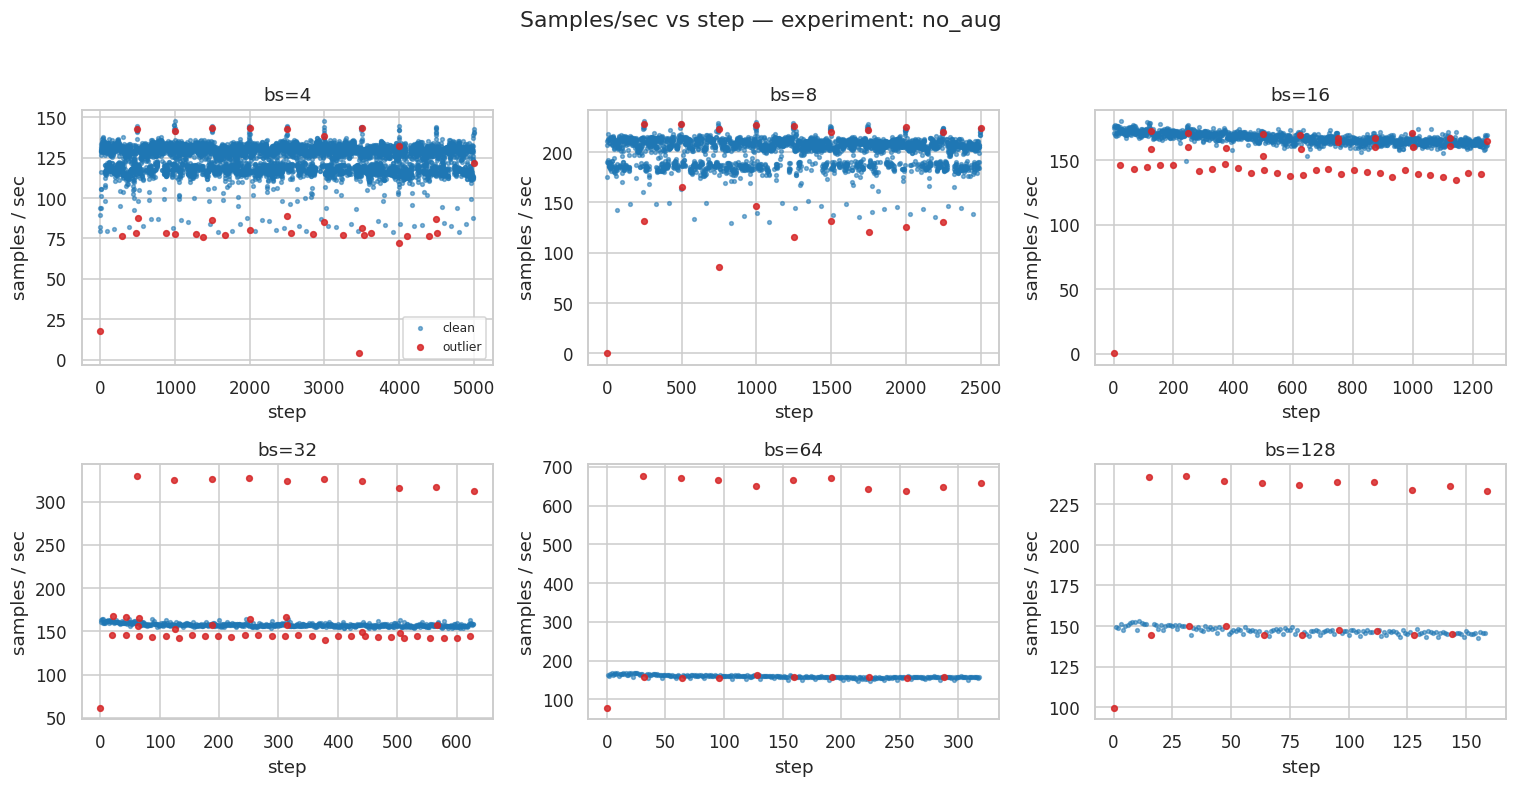

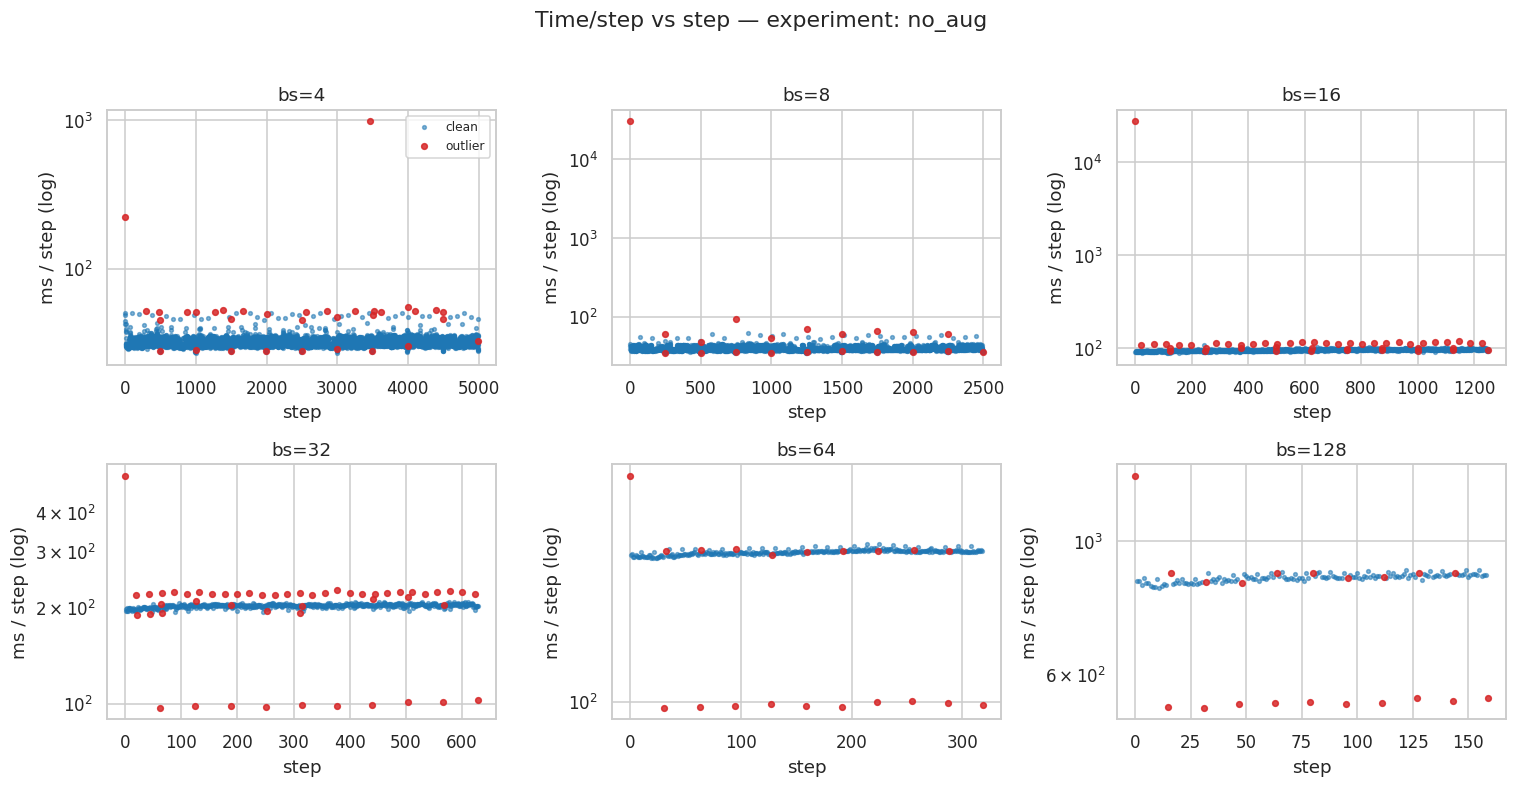

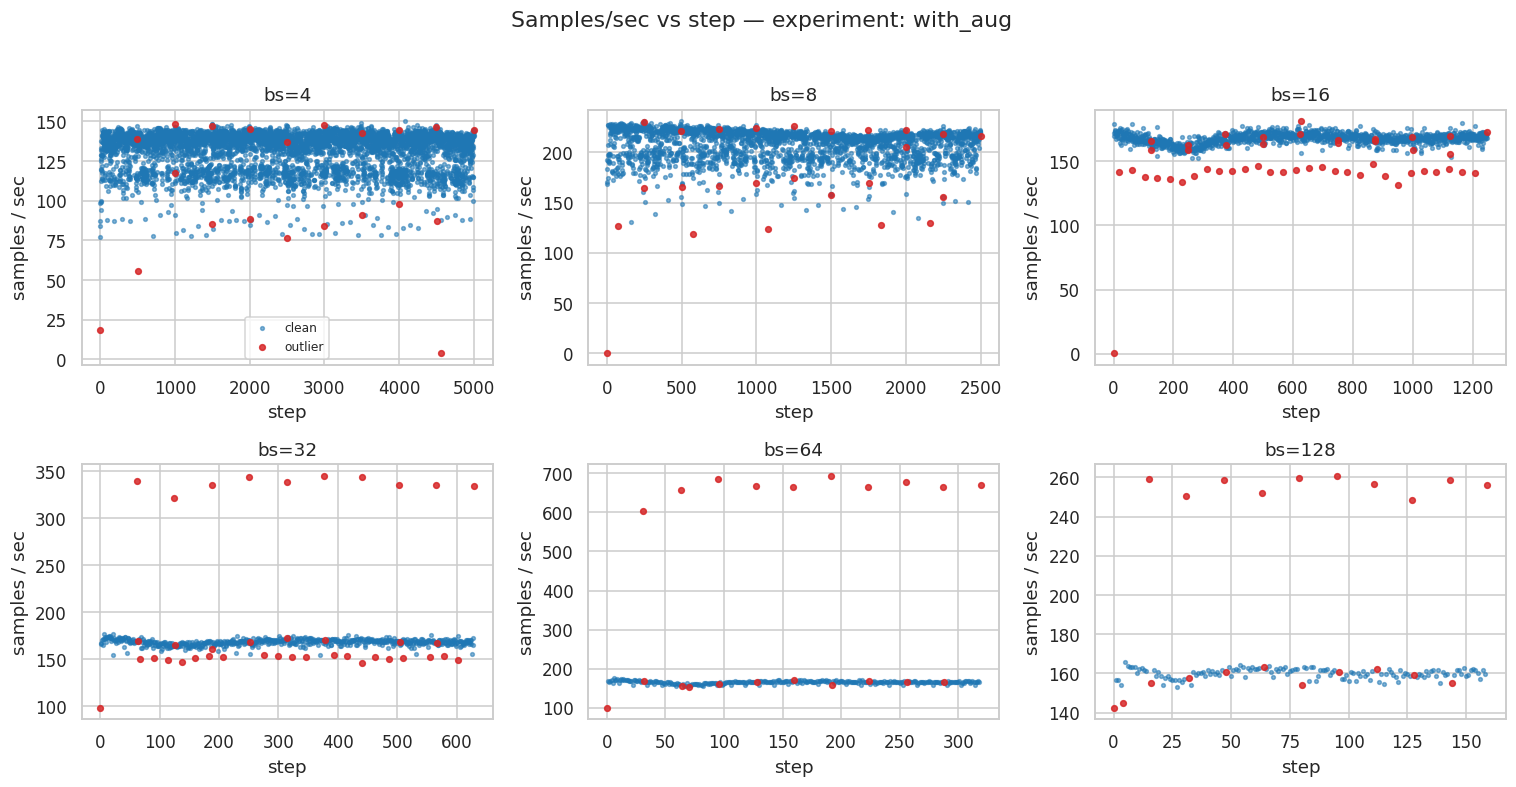

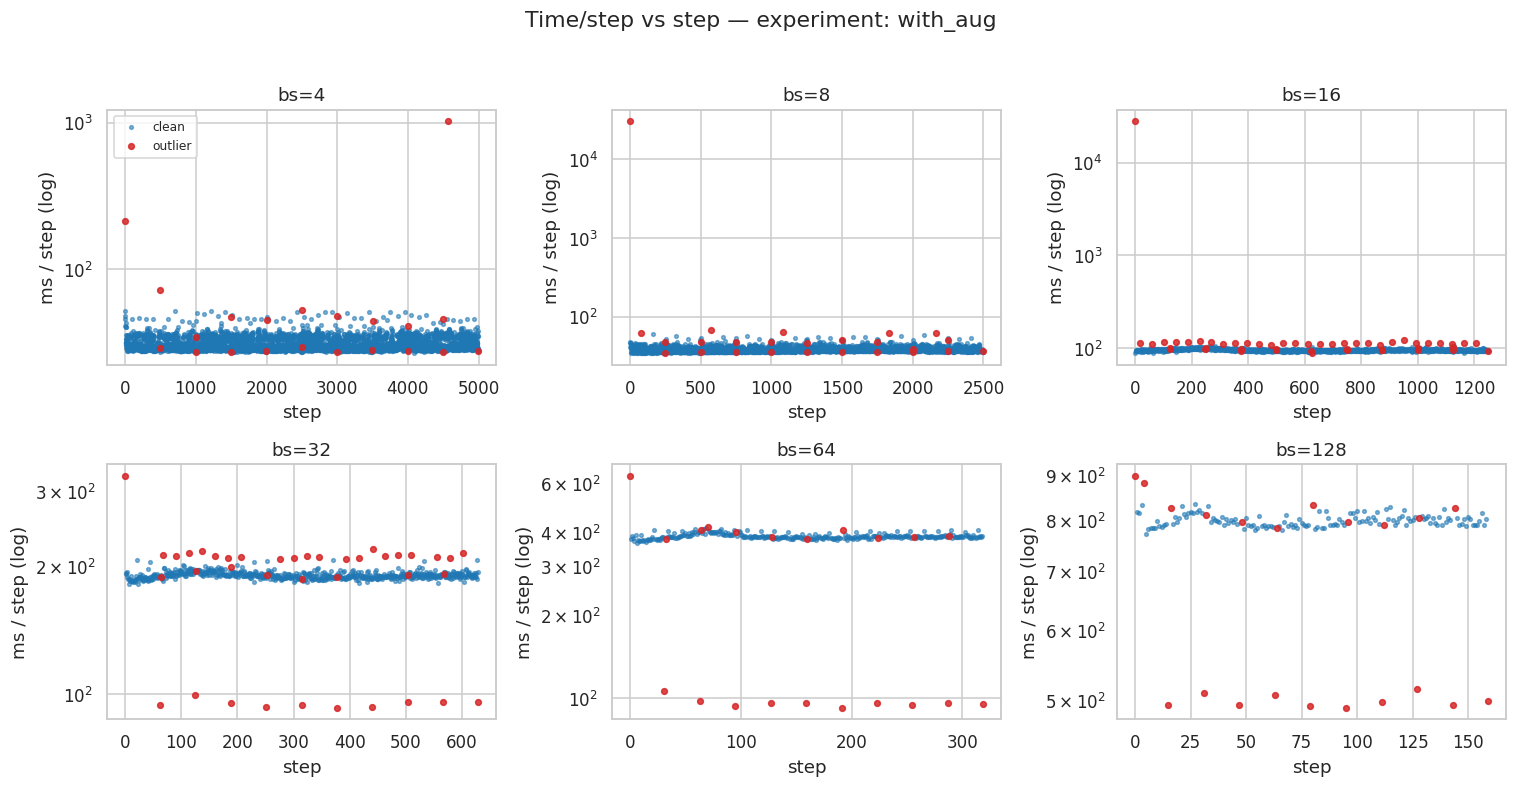

In [4]:
for exp in ["no_aug", "with_aug"]:
    df_exp = DF[DF["experiment"] == exp]
    scatter_outliers(df_exp, "samples_per_sec",
                     f"Samples/sec vs step — experiment: {exp}",
                     "samples / sec",
                     batch_sizes=EXPECTED_BATCH_SIZES)
    scatter_outliers(df_exp, "time_per_step_ms",
                     f"Time/step vs step — experiment: {exp}",
                     "ms / step (log)",
                     batch_sizes=EXPECTED_BATCH_SIZES,
                     ylog=True)

### 3.2 Throughput

`SUMMARY` aggregates clean (non-outlier) steps per `(experiment, batch_size)` into three robust percentiles:

- **`median_samples_per_sec`** — the primary throughput estimate; used for all inter-batch-size comparisons (criterion 1 in §2.2).
- **`p10_samples_per_sec` / `p90_samples_per_sec`** — the 10th and 90th percentiles, capturing the steady-state low and high. A narrow p10–p90 band indicates stable throughput; a wide band suggests measurement noise or CPU–GPU pipeline jitter.
- **`median_time_per_step_ms`** — used for the compute-bound inflection check (criterion 2 in §2.2).

In [5]:
SUMMARY = throughput_summary(DF)
SUMMARY

,experiment,batch_size,p10_samples_per_sec,median_samples_per_sec,p90_samples_per_sec,median_time_per_step_ms
0,no_aug,4,114.9768,127.2376,132.7930,31.4372
1,no_aug,8,183.3744,205.9562,213.4951,38.8432
2,no_aug,16,162.2815,167.0686,172.3774,95.7690
3,no_aug,32,155.5903,157.2350,160.3541,203.5170
4,no_aug,64,154.6391,158.5980,163.8240,403.5361
5,no_aug,128,144.7734,146.9285,150.4072,871.1722
6,with_aug,4,113.7247,136.2342,142.6829,29.3612
7,with_aug,8,186.9750,213.0299,222.6210,37.5534
8,with_aug,16,161.9203,167.9255,172.4826,95.2804
9,with_aug,32,164.0205,168.4691,171.7321,189.9458


- From the graphs below, it is seen that the throughput flattens starting from batch = 16 (the peak is at batch = 8)
- Time per step is doubling with the batch size starting from batch = 16, while staying roughly constant at batch sizes 4 and 8 (GPU sits at 45–52 % utilisation as you will see below, so step time is dominated by fixed per-step overhead like kernel launches, dataloader handoff, logging). The jump from about 40 ms (batch size = 8) to almost 100 ms per step (batch size = 16) is a crossover from sub-linear (overhead-bound) to linear (compute-bound)

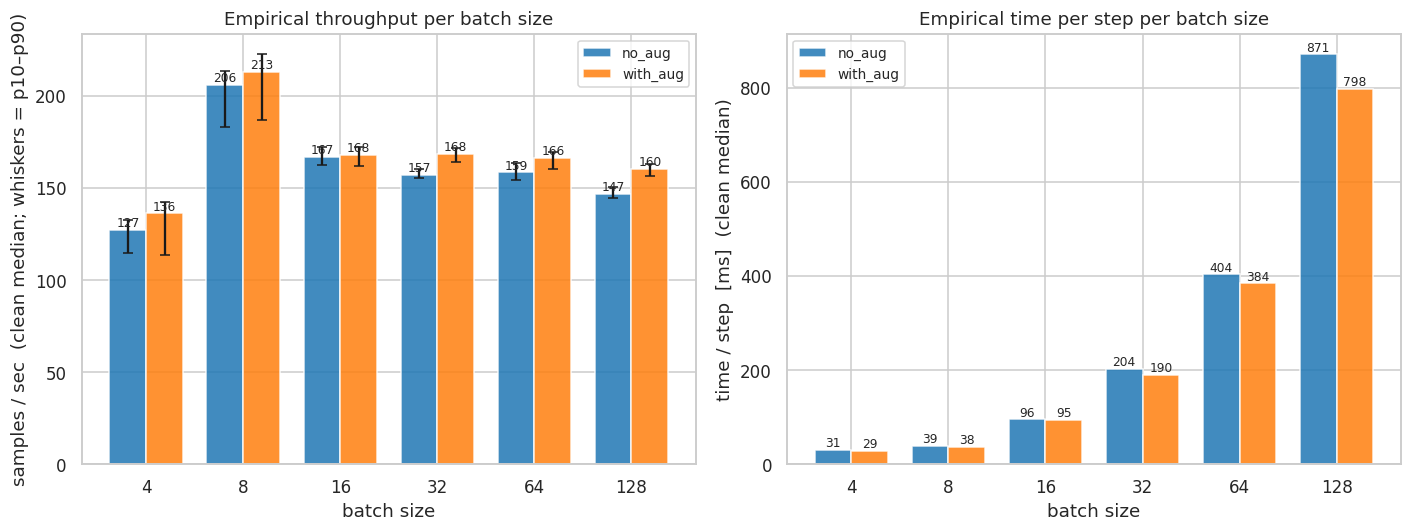

In [6]:
fig = plot_empirical_throughput_and_timing(SUMMARY, batch_sizes=EXPECTED_BATCH_SIZES)

### 3.3 Throughput stability
Troughout traces — `samples_per_sec` over training steps for each batch size within a condition, with outliers. Each trace is a single run; dashed lines mark epoch boundaries.

What to look for:
- **Stability** — traces should be flat after the first few steps (warm-up). High variance later in training indicates DataLoader jitter or thermal throttling.
- **Ordering** — traces should be rank-ordered consistently with the bar-chart medians above
- **Epoch boundaries** — brief throughput dips at epoch boundaries (data re-shuffle + DataLoader restart) are expected; the rule-based pass flags these steps unconditionally (`epoch_last_high` / `epoch_first_low`) and excludes them from all statistics.

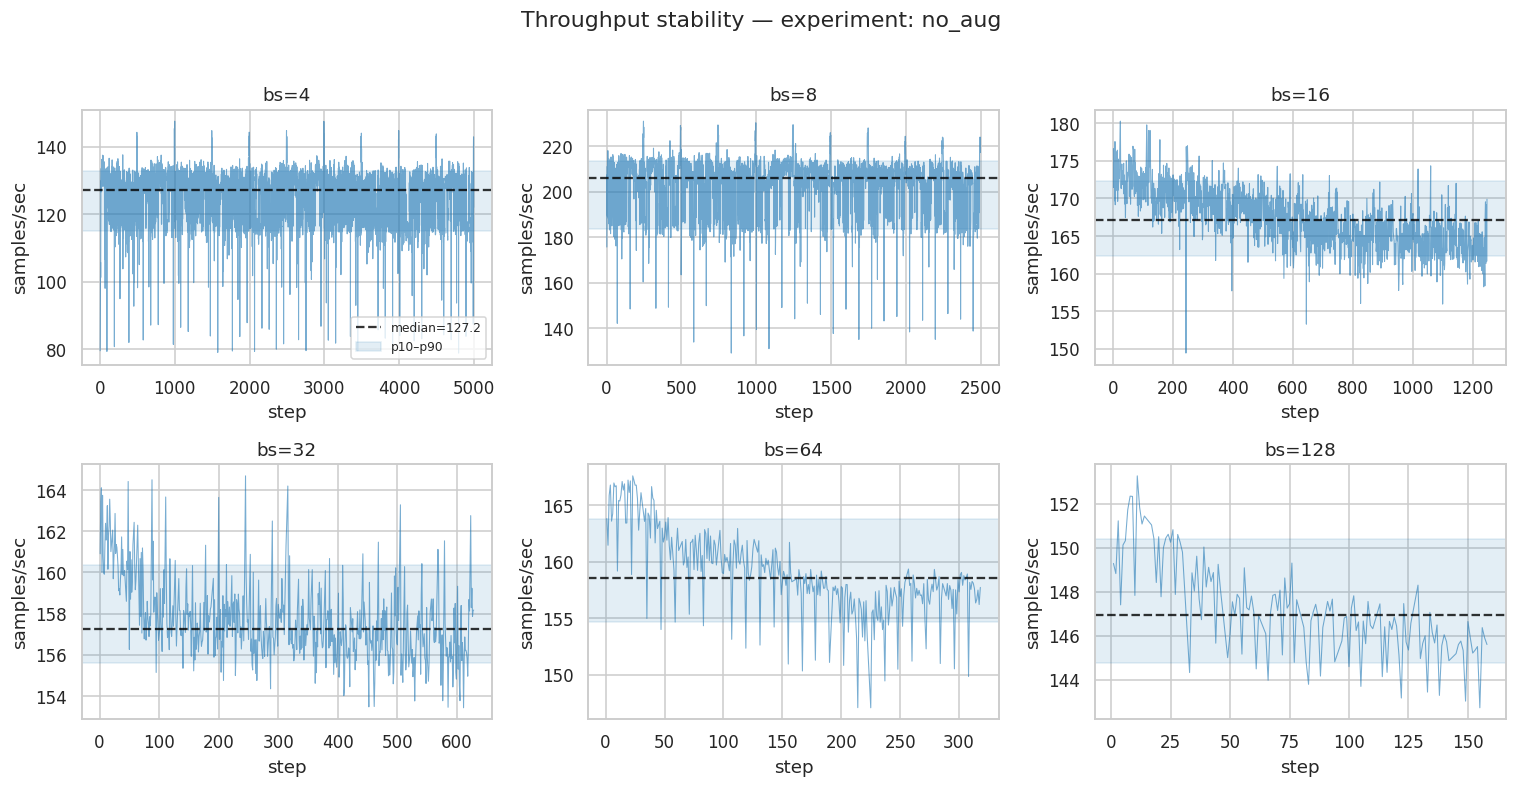

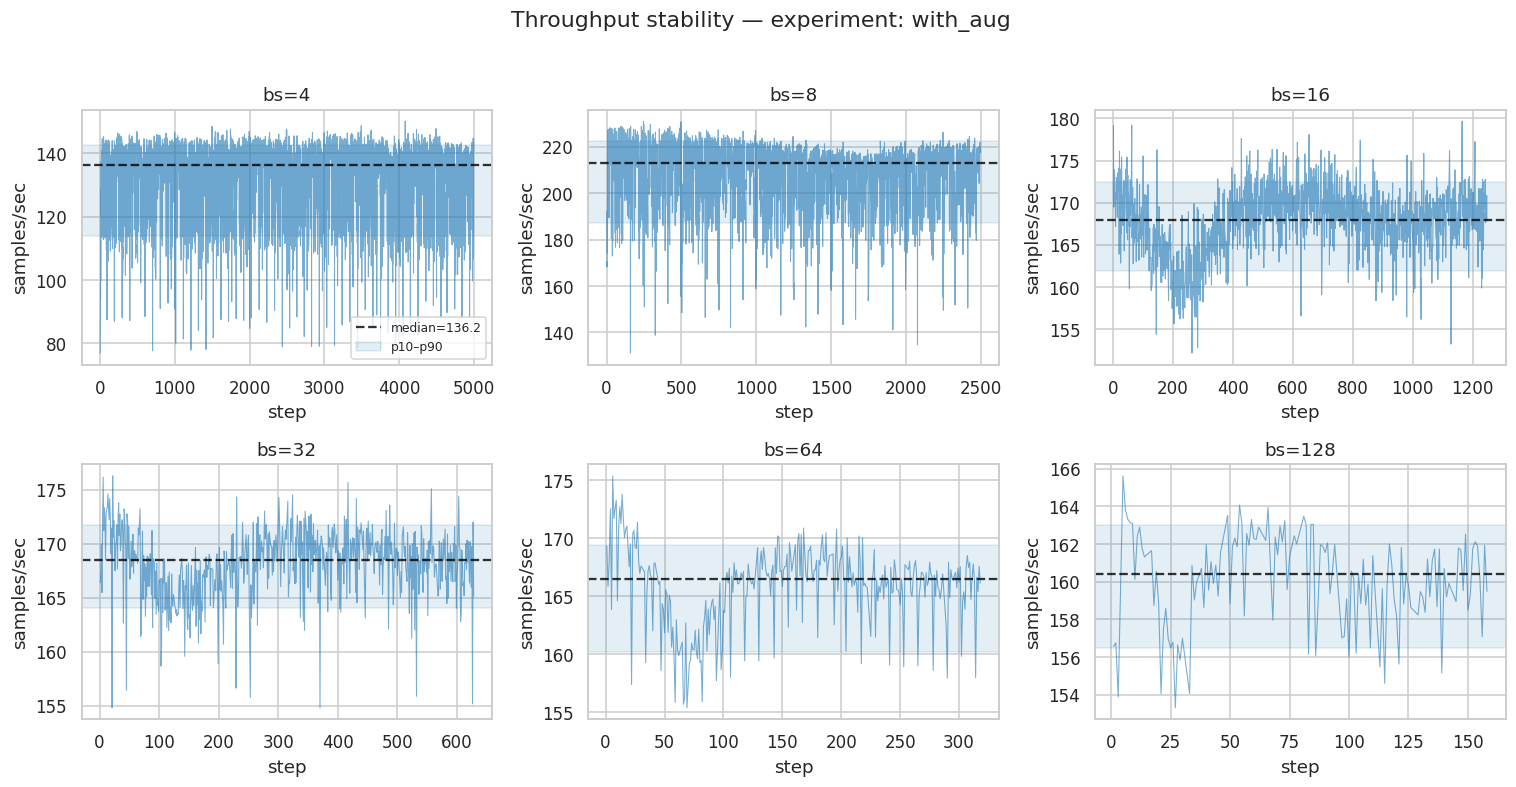

In [7]:
for exp in ["no_aug", "with_aug"]:
    plot_throughput_traces(DF, exp, batch_sizes=EXPECTED_BATCH_SIZES, max_epochs=MAX_EPOCHS_SWEEP)

**Observed** (against the three expectations above):

- **Stability** — means are stationary, but the variance pattern differs from the expectation: noise is largest at bs=4–8 and persistent from the first step (downward spikes to ~130–140 sps at bs=8) which is a steady DataLoader jitter. The compute-bound runs instead start *fast* and decay: bs=16 no_aug drifts ≈172 → ≈165 sps over the run; bs=128 holds ≈151–153 sps for its first ~30 steps before settling at ≈146–147. That is a thermal signature (a cool GPU boosts clocks, then throttles the clock down) and it appears only in the batch sizes where GPU compute speed is the limiting factor for how long each step takes. 
- **Ordering** — holds as per bar plots above
- **Epoch boundaries** — not separable by eye: at bs=4–8 the downward spikes occur far more often than once per epoch (≈250 steps/epoch at bs=8)
- **Impact on the decision** — the ~3–5 % thermal drift flatters early-run throughput equally across the compute-bound sizes, so the ranking and the bs=16 choice are unaffected.

### 3.3 GPU utilisation & memory

Per-step `gpu_util_pct` and `gpu_mem_gb` aggregated to **median** (utilisation) and **peak** (memory) per `(experiment, batch_size)`.

**Utilisation (`gpu_util_pct`)** tracks whether the GPU compute engines or the DataLoader pipeline is the throughput bottleneck at each batch size (criterion 3 in §2.2):
- Below ~50 %: the GPU is idle while waiting for data — increasing `batch_size` amortises per-sample DataLoader overhead and raises utilisation.
- 50 %–80 %: transitional zone; both CPU pipeline and GPU contribute to the bottleneck.
- ≥ 80 %: the GPU is genuinely saturated — the bottleneck has shifted to compute, which is the intended training regime. Further increases in `batch_size` yield diminishing utilisation returns.

**Memory (`gpu_mem_gb`)** is checked against the **16 GB T4 envelope**. The DDP viability check requires that peak memory at the recommended `bs` leaves room for:
- DDP gradient buckets (~100–200 MB for a U-Net at this scale)
- Activation memory from the forward pass (scales roughly linearly with `batch_size`)
- Framework overhead and CUDA context (~300–500 MB fixed)

A peak memory of ≤ 6–7 GB at the recommended `bs` provides comfortable DDP headroom; the run can be doubled to 2× T4 without OOM risk.

,experiment,batch_size,median_gpu_util_pct,median_gpu_mem_gb,peak_gpu_mem_gb
0,no_aug,4,45.0000,0.0536,0.2203
1,no_aug,8,52.0000,0.0569,0.3894
2,no_aug,16,77.0000,0.0631,0.7220
3,no_aug,32,88.0000,0.0778,1.3854
4,no_aug,64,100.0000,0.1018,2.7408
5,no_aug,128,94.0000,0.1523,5.3634
6,with_aug,4,45.0000,0.0536,0.2222
7,with_aug,8,52.5000,0.0569,0.3933
8,with_aug,16,79.5000,0.0631,0.7220
9,with_aug,32,88.0000,0.0778,1.4004


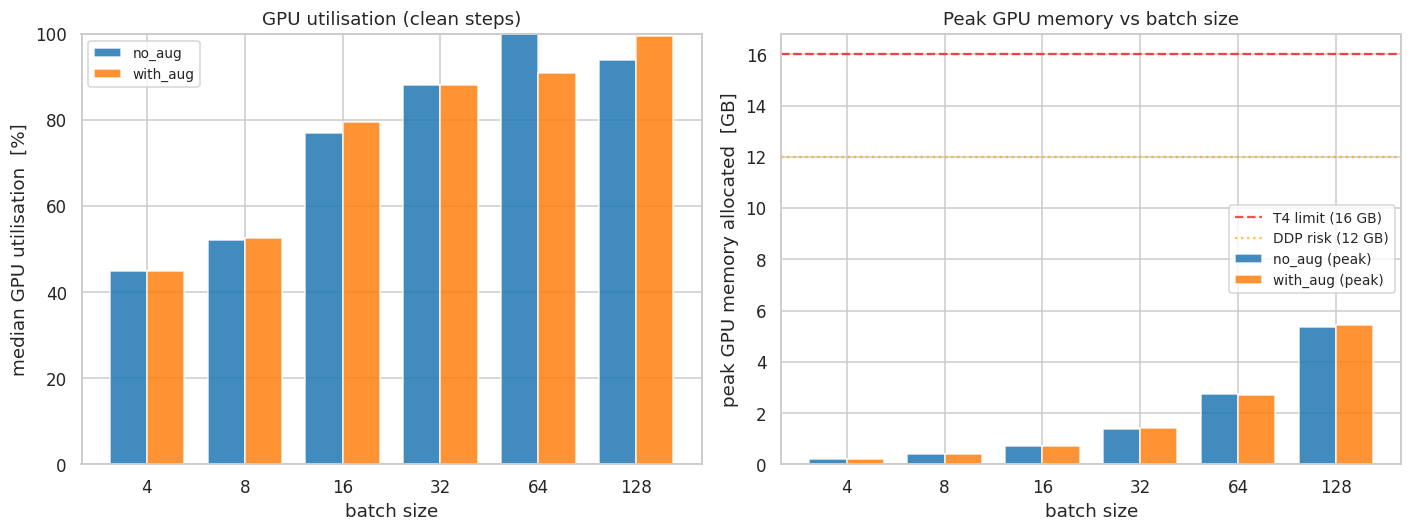

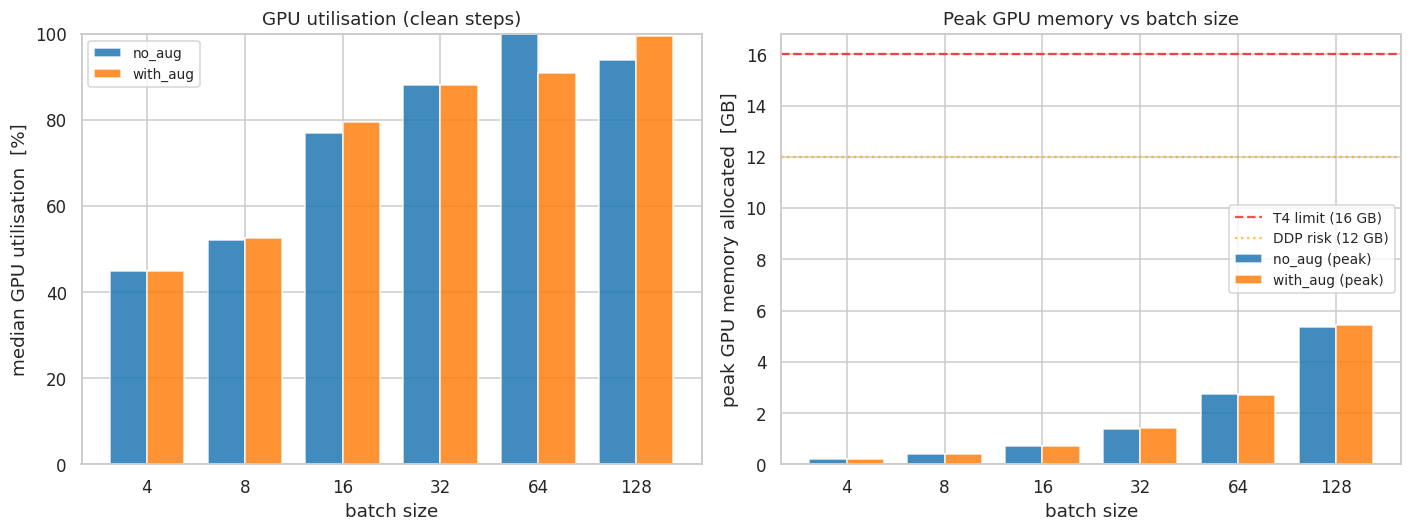

In [8]:
GPU_TBL = gpu_summary(DF)
display(GPU_TBL)
plot_gpu_panels(GPU_TBL, batch_sizes=EXPECTED_BATCH_SIZES)

**Observed:**

- **Utilisation** — stalls at 45–53 % across the overhead-bound sizes (bs=4–8), then first reaches the ≥ 80 % saturation criterion at bs=16 and stays saturated beyond (88–100 %) — consistent with bs=16 being the entry point of the compute-bound regime seen in the time-per-step data.
- **Memory** — peak allocation roughly doubles with batch size, i.e. activations dominate the footprint; at bs=16 the 0.72 GB peak leaves some 15 GB of the T4 envelope free — ample headroom for DDP buckets and pytorch framework overhead.

### 3.4 Loss convergence (context only)

Step-level `train_loss` per batch size, shown for **sanity checking only**

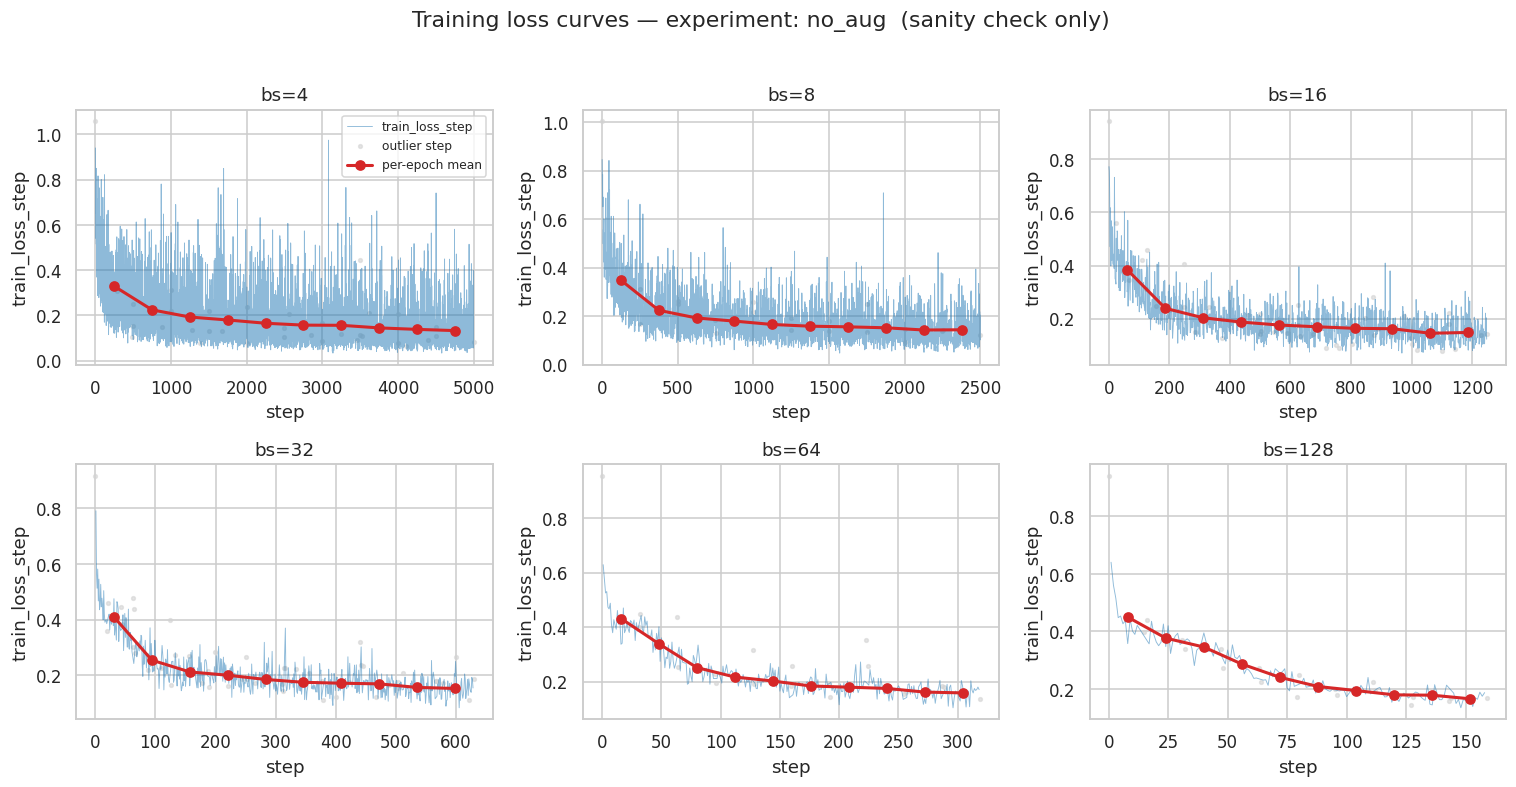

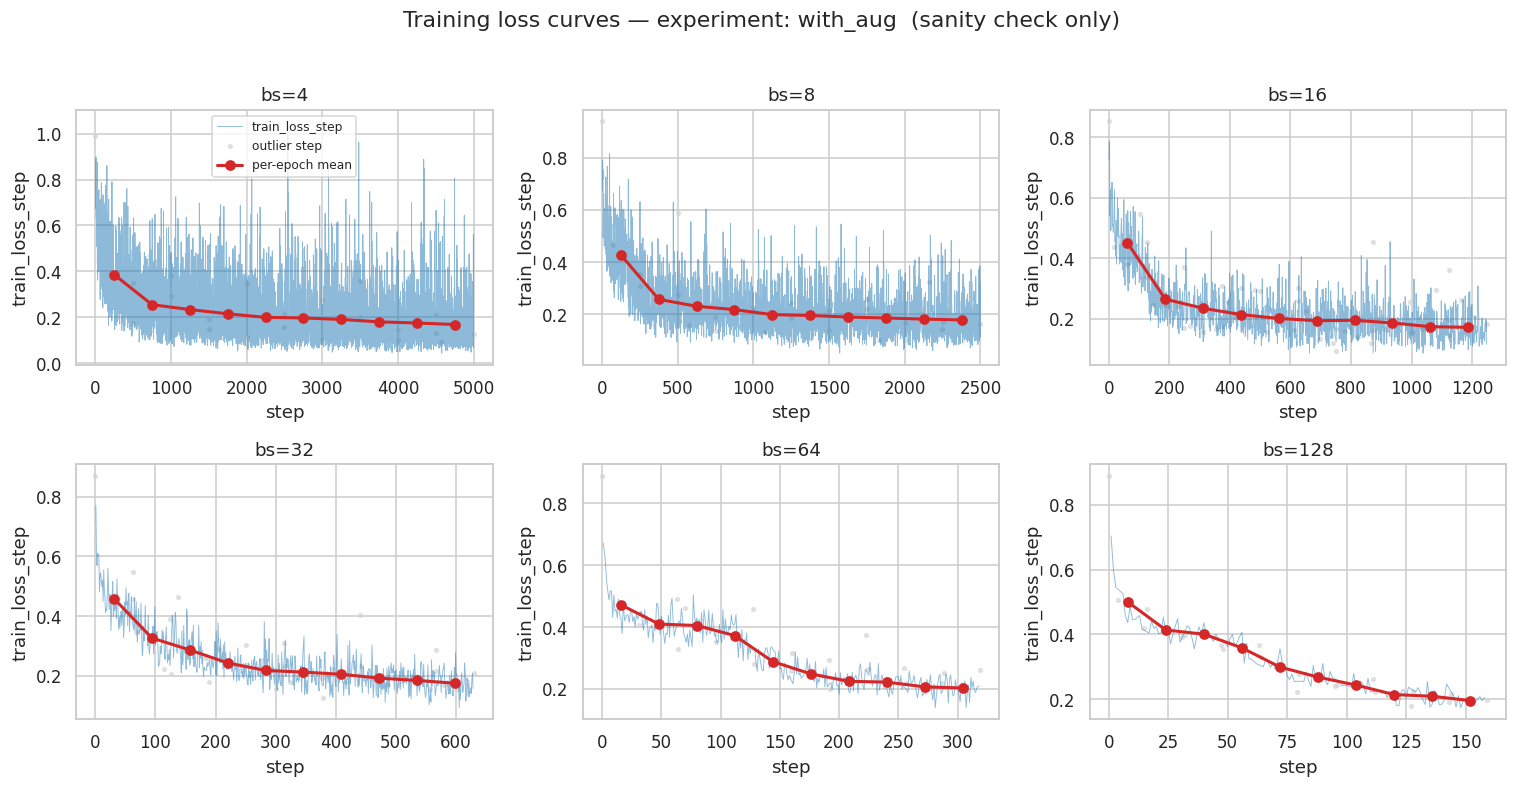

In [9]:
for exp in ["no_aug", "with_aug"]:
    plot_loss_curves(DF, exp, batch_sizes=EXPECTED_BATCH_SIZES, max_epochs=MAX_EPOCHS_SWEEP)

## 4. Conclusion

In [10]:
# ── Facts: every number the recommendation prose needs, in one dict ─────────
FACTS = recommendation_facts(SUMMARY, GPU_TBL, RECOMMENDED_BS)

In [11]:
def _fmt(x):
    if x is None or (isinstance(x, float) and x != x):  # None or NaN
        return "n/a"
    return f"{x}"


bs_rec      = FACTS["recommended_bs"]
per_exp     = FACTS["per_exp"]
peak_no_sps = per_exp["no_aug"]["peak_median_sps"]
peak_aug_sps= per_exp["with_aug"]["peak_median_sps"]
peak_no_bs  = per_exp["no_aug"]["peak_bs"]
sps_rec_no  = per_exp["no_aug"]["median_at_recommended_sps"]
sps_rec_aug = per_exp["with_aug"]["median_at_recommended_sps"]
util_no     = FACTS["gpu_util_at_recommended"].get("no_aug")
util_aug    = FACTS["gpu_util_at_recommended"].get("with_aug")
peak_mem    = FACTS["gpu_mem"].get(bs_rec)
aug_pen     = FACTS.get("aug_penalty_pct_at_recommended")

display(Markdown(f"""
### Recommended batch size: **bs = {bs_rec}**

#### 1. Throughput plateau
Throughput peaks at bs={peak_no_bs} ({_fmt(peak_no_sps)} / {_fmt(peak_aug_sps)} sps no_aug / with_aug),
then settles onto a flat plateau from bs={bs_rec} onward ({_fmt(sps_rec_no)} / {_fmt(sps_rec_aug)} sps,  about 80 % of peak).

#### 2. Compute-bound entry
Median time-per-step is nearly flat from bs=4 to 8 (×1.2–1.3 per doubling — overhead-bound),
jumps ×2.5 at 8→16 (the crossover), and scales linearly (≈×2 per doubling) from bs=16 onward.
bs={bs_rec} is the smallest batch inside the compute-bound regime.

#### 3. GPU saturation
Median utilisation first reaches ~80 % at bs={bs_rec} ({_fmt(util_no)} % / {_fmt(util_aug)} %) and
stays at 88–100 % beyond; at bs=4–8 the GPU idles at 45–53 % waiting on the DataLoader.

#### Memory headroom for DDP
Peak `gpu_mem_gb` at bs={bs_rec} is **{_fmt(peak_mem)} GB** — under 5 % of the 16 GB T4 envelope,
ample room for DDP buckets and framework overhead.

#### Augmentation effect
Throughput cost of augmentations at bs={bs_rec}: **{_fmt(aug_pen)} %** — augmentations do
*not* shift the optimal batch size on this hardware."""))



### Recommended batch size: **bs = 16**

#### 1. Throughput plateau
Throughput peaks at bs=8 (205.96 / 213.03 sps no_aug / with_aug),
then settles onto a flat plateau from bs=16 onward (167.07 / 167.93 sps,  about 80 % of peak).

#### 2. Compute-bound entry
Median time-per-step is nearly flat from bs=4 to 8 (×1.2–1.3 per doubling — overhead-bound),
jumps ×2.5 at 8→16 (the crossover), and scales linearly (≈×2 per doubling) from bs=16 onward.
bs=16 is the smallest batch inside the compute-bound regime.

#### 3. GPU saturation
Median utilisation first reaches ~80 % at bs=16 (77.0 % / 79.5 %) and
stays at 88–100 % beyond; at bs=4–8 the GPU idles at 45–53 % waiting on the DataLoader.

#### Memory headroom for DDP
Peak `gpu_mem_gb` at bs=16 is **0.72 GB** — under 5 % of the 16 GB T4 envelope,
ample room for DDP buckets and framework overhead.

#### Augmentation effect
Throughput cost of augmentations at bs=16: **-0.51 %** — augmentations do
*not* shift the optimal batch size on this hardware.